# GLOBAL DEMOGRAPHIC STRUCTURE ANALYSIS (GDS-2025)
## Worldwide Data Scraping, Cleaning, and Comprehensive Statistical Analysis aross 233 Countries

#### Students: Elen Yeghiazaryan / Milena Yeganyan
#### Course: Algorithms and Programming Language (APL)
#### Professor: Varazdat Avetisyan  
##### Date: November 2025

Countries in the world by population (2025) - https://www.worldometers.info/world-population/population-by-country/

# ***PROBLEM STATEMENT***

The global population is growing inconsistently, with significant differences in population size, density, fertility rates, urbanization, and migration patterns across countries.

Understanding these demographic factors is critical for planning infrastructure, healthcare, education, and economic policies. However, raw population data is often complex, inconsistent, and difficult to interpret, making it challenging to identify trends, relationships, and insights.

This project aims to clean, analyze, and visualize population data to uncover patterns in population distribution, land area, fertility, urbanization, and migration.

# ***Stage 1: DATA SCRAPING***

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from bs4 import BeautifulSoup
import re
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from google.colab import files
from scipy.stats import shapiro
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

In [ ]:
# 1. Fetch the HTML page
url = "https://www.worldometers.info/world-population/population-by-country/"
response = requests.get(url)
response.raise_for_status()

# 2. Parsing the HTML
soup = BeautifulSoup(response.text, "html.parser")

# 3. Finding the main table
table_html = str(soup.find("table"))

# 4. Converting table to DataFrame safely
df = pd.read_html(StringIO(table_html))[0]

# 5. Saving CSV
df.to_csv("scraped_data.csv", index=False)

print("Saved as scraped_data.csv")

from google.colab import files
files.download("scraped_data.csv")

Saved as scraped_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***Stage 2: DATA CLEANING***

In [ ]:
# loading data
df = pd.read_csv("scraped_data.csv")
df.info()
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   #                        233 non-null    int64  
 1   Country (or dependency)  233 non-null    object 
 2   Population 2025          233 non-null    int64  
 3   Yearly Change            233 non-null    object 
 4   Net Change               233 non-null    object 
 5   Density (P/KmÂ²)         233 non-null    int64  
 6   Land Area (KmÂ²)         233 non-null    int64  
 7   Migrants (net)           233 non-null    object 
 8   Fert. Rate               233 non-null    float64
 9   Median Age               233 non-null    float64
 10  Urban Pop %              210 non-null    object 
 11  World Share              233 non-null    object 
dtypes: float64(2), int64(4), object(6)
memory usage: 22.0+ KB


,#,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/KmÂ²),Land Area (KmÂ²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,India,1463865525,0.89%,12929734,492,2973190,"â495,753",1.94,28.8,37.1%,17.78%
1,2,China,1416096094,â0.23%,"â3,225,184",151,9388211,"â268,126",1.02,40.1,67.5%,17.20%
2,3,United States,347275807,0.54%,1849236,38,9147420,1230663,1.62,38.5,82.8%,4.22%
3,4,Indonesia,285721236,0.79%,2233305,158,1811570,"â39,509",2.10,30.4,59.6%,3.47%
4,5,Pakistan,255219554,1.57%,3950390,331,770880,"â1,235,336",3.50,20.6,34.4%,3.10%
5,6,Nigeria,237527782,2.08%,4848304,261,910770,"â15,258",4.30,18.1,54.9%,2.89%
6,7,Brazil,212812405,0.38%,813832,25,8358140,"â217,283",1.60,34.8,91.4%,2.59%
7,8,Bangladesh,175686899,1.22%,2124535,1350,130170,"â402,100",2.11,26.0,42.6%,2.13%
8,9,Russia,143997393,â0.57%,"â823,030",9,16376870,"â251,822",1.47,40.3,75%,1.75%
9,10,Ethiopia,135472051,2.58%,3412284,135,1000000,24054,3.81,19.1,22.5%,1.65%


## **2.1 Cleaning odd characters**

In [ ]:
# Columns that need numeric cleaning
cols_clean_strong = ["Yearly Change", "Net Change", "Migrants (net)"]

# Columns that need gentle cleaning (only remove %, comma, convert to numeric)
cols_clean_soft = ["Urban Pop %", "World Share"]

def clean_column_strong(series):
#Aggressive cleaning for change columns like Net/Yearly/Migrants.
    s = series.astype(str).str.strip()

    # About minus signs
    s = s.str.replace('−', '-', regex=False)
    s = s.str.replace('–', '-', regex=False)
    s = s.str.replace('—', '-', regex=False)

    # Convert (123) → -123
    s = s.str.replace(r'^\((.*?)\)$', r'-\1', regex=True)

    # Fixing odd characters like â
    s = s.str.replace('â', '-', regex=False)

    # Remove commas and percent
    s = s.str.replace(',', '', regex=False)
    s = s.str.replace('%', '', regex=False)

    # Keep only digits, dot and minus
    s = s.str.replace(r'[^\d\.\-]', '', regex=True)

    return pd.to_numeric(s, errors="coerce")

def clean_column_soft(series):
    s = series.astype(str).str.strip()

    # Remove % and commas
    s = s.str.replace('%', '', regex=False)
    s = s.str.replace(',', '', regex=False)

    return pd.to_numeric(s, errors="coerce")

# CLEANING
for col in cols_clean_strong:
    if col in df.columns:
        df[col] = clean_column_strong(df[col])

for col in cols_clean_soft:
    if col in df.columns:
        df[col] = clean_column_soft(df[col])

# fix column names that contain Â
df.columns = df.columns.str.replace('Â', '', regex=False)

# saving
df.to_csv("cleaned_chars.csv", index=False)
print("Saved as cleaned_chars.csv")

from google.colab import files
files.download("cleaned_chars.csv")

Saved as cleaned_chars.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#loading
df.info()
df.head(10)
df = pd.read_csv("cleaned_chars.csv")
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 233 entries, 0 to 232
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   #                        233 non-null    int64  
 1   Country (or dependency)  233 non-null    object 
 2   Population 2025          233 non-null    int64  
 3   Yearly Change            233 non-null    float64
 4   Net Change               233 non-null    int64  
 5   Density (P/Km²)          233 non-null    int64  
 6   Land Area (Km²)          233 non-null    int64  
 7   Migrants (net)           233 non-null    int64  
 8   Fert. Rate               233 non-null    float64
 9   Median Age               233 non-null    float64
 10  Urban Pop %              210 non-null    float64
 11  World Share              233 non-null    float64
dtypes: float64(5), int64(6), object(1)
memory usage: 22.0+ KB


,#,Country (or dependency),Population 2025,Yearly Change,Net Change,Density (P/Km²),Land Area (Km²),Migrants (net),Fert. Rate,Median Age,Urban Pop %,World Share
0,1,India,1463865525,0.89,12929734,492,2973190,-495753,1.94,28.8,37.1,17.78
1,2,China,1416096094,-0.23,-3225184,151,9388211,-268126,1.02,40.1,67.5,17.20
2,3,United States,347275807,0.54,1849236,38,9147420,1230663,1.62,38.5,82.8,4.22
3,4,Indonesia,285721236,0.79,2233305,158,1811570,-39509,2.10,30.4,59.6,3.47
4,5,Pakistan,255219554,1.57,3950390,331,770880,-1235336,3.50,20.6,34.4,3.10
5,6,Nigeria,237527782,2.08,4848304,261,910770,-15258,4.30,18.1,54.9,2.89
6,7,Brazil,212812405,0.38,813832,25,8358140,-217283,1.60,34.8,91.4,2.59
7,8,Bangladesh,175686899,1.22,2124535,1350,130170,-402100,2.11,26.0,42.6,2.13
8,9,Russia,143997393,-0.57,-823030,9,16376870,-251822,1.47,40.3,75.0,1.75
9,10,Ethiopia,135472051,2.58,3412284,135,1000000,24054,3.81,19.1,22.5,1.65


## **2.2 Missing values**

In [ ]:
# Checking how many missing values are in each column
print("Missing values before cleaning:")
print(df.isna().sum())

Missing values before cleaning:
#                           0
Country (or dependency)     0
Population 2025             0
Yearly Change               0
Net Change                  0
Density (P/Km²)             0
Land Area (Km²)             0
Migrants (net)              0
Fert. Rate                  0
Median Age                  0
Urban Pop %                23
World Share                 0
dtype: int64


In [ ]:
# Replacing missing values (NaN) in numeric columns with 0 for working exactly with data
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(0)

#saving
df.to_csv("after_missing.csv", index=False)
print("Saved as after_missing.csv")

from google.colab import files
files.download("after_missing.csv")

Saved as after_missing.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Checking how many missing values each column has after cleaning
print("Missing values before cleaning:")
print(df.isna().sum())

Missing values before cleaning:
#                          0
Country (or dependency)    0
Population 2025            0
Yearly Change              0
Net Change                 0
Density (P/Km²)            0
Land Area (Km²)            0
Migrants (net)             0
Fert. Rate                 0
Median Age                 0
Urban Pop %                0
World Share                0
dtype: int64


## **2.3 Removing duplicating rows**

In [ ]:
# Remove duplicate
df_analysis = df.copy()
before = len(df_analysis)

# then show how many were deleted
df_analysis = df_analysis.drop_duplicates()

print(f"Removed {before - len(df_analysis)} duplicate rows.")

Removed 0 duplicate rows.


In [ ]:
# Saveing
df.to_csv("cleaned_data.csv", index=False)
print("\nCleaned Data is ready.")

from google.colab import files
files.download("cleaned_data.csv")


Cleaned Data is ready.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***Stage 3: DATA PREPROCESSING***

## **3.1 Feature Engineering**

In [ ]:
# if Urban Pop % is exactly 100, then we need to avoid devision by 0
df_analysis['Urban Pop %'] = df_analysis['Urban Pop %'].replace(100, 99.999)

# creating new feautre (urban rural ratio)
df_analysis['Urban Rural Ratio'] = df_analysis['Urban Pop %'] / (100 - df_analysis['Urban Pop %'])

# showing first 10 rows
print(df_analysis[['Urban Pop %', 'Urban Rural Ratio']].head(10).to_string())

# saving
df_analysis.to_csv("world_pop_cleaned.csv", index=False)
print("\nNew feature added.")



   Urban Pop %  Urban Rural Ratio
0         37.1           0.589825
1         67.5           2.076923
2         82.8           4.813953
3         59.6           1.475248
4         34.4           0.524390
5         54.9           1.217295
6         91.4          10.627907
7         42.6           0.742160
8         75.0           3.000000
9         22.5           0.290323

New feature added.


In this step, we created a new feature called the Urban-Rural Ratio to improve our analysis.
We calculated it by dividing the Urban Population percentage by the Rural Population percentage (100 - Urban Pop %).

For example, if a country has 67.5% urban population, the rural population is 32.5%, and the ratio becomes 67.5 / 32.5 ≈ 2.07.

This means the country has about twice as many people living in urban areas compared to rural areas.

## **3.2 Data Transformation**

In [ ]:
# copying for not changing the original
df_cleaned = df_analysis.copy()

# choosing only numeric columns and also exclude the first # numbering column
numeric_columns = [col for col in df_cleaned.select_dtypes(include=np.number).columns if col not in ['Country', '#']]

# Standardization (Z-score normalization)
scaler = StandardScaler()
df_standardized = df_cleaned.copy()
df_standardized[numeric_columns] = scaler.fit_transform(df_cleaned[numeric_columns])

# Normalization (Min-Max scaling)
minmax_scaler = MinMaxScaler()
df_normalized = df_cleaned.copy()
df_normalized[numeric_columns] = minmax_scaler.fit_transform(df_cleaned[numeric_columns])

# display several rows for checking
print("Cleaned DataFrame:")
print(df_cleaned.head())
print("\nStandardized DataFrame:")
print(df_standardized.head())
print("\nNormalized DataFrame:")
print(df_normalized.head())



Cleaned DataFrame:
   # Country (or dependency)  Population 2025  Yearly Change  Net Change  \
0  1                   India       1463865525           0.89    12929734   
1  2                   China       1416096094          -0.23    -3225184   
2  3           United States        347275807           0.54     1849236   
3  4               Indonesia        285721236           0.79     2233305   
4  5                Pakistan        255219554           1.57     3950390   

   Density (P/Km²)  Land Area (Km²)  Migrants (net)  Fert. Rate  Median Age  \
0              492          2973190         -495753        1.94        28.8   
1              151          9388211         -268126        1.02        40.1   
2               38          9147420         1230663        1.62        38.5   
3              158          1811570          -39509        2.10        30.4   
4              331           770880        -1235336        3.50        20.6   

   Urban Pop %  World Share  Urban Rural Ratio  


STANDARDIZATION

India’s population is 1,463,865,525.
After standardization, this value becomes 10.28.
This means India’s population is 10 standard deviations above the average, showing how extremely large it is compared to other countries.

NORMALIZATION

After normalization, India’s population becomes 1.0.
This happens because it is the highest population value, so Min–Max scaling turns it into the maximum value on the 0–1 scale.
This shows we understand that standardization measures how far a value is from the mean, while normalization places all values on the same 0–1 range.

In [ ]:
# saving
df_cleaned.to_csv('world_pop_cleaned.csv', index=False)
df_standardized.to_csv('world_pop_standardized.csv', index=False)
df_normalized.to_csv('world_pop_normalized.csv', index=False)

print("DataFrames saved to CSV files successfully!")

DataFrames saved to CSV files successfully!


In [ ]:
from google.colab import files
files.download('world_pop_cleaned.csv')
files.download('world_pop_standardized.csv')
files.download('world_pop_normalized.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# ***Stage 4: DATA ANALYSIS (Exploratory Data Analysis (EDA))***

## **4.1 Descriptive Statistics**

In [ ]:
# loading already cleaned dataset
df_analysis = pd.read_csv("world_pop_cleaned.csv")

# removing '#' column if it exists
df_num = df_analysis.drop(columns=['#'], errors='ignore')

# only numeric columns
numeric_cols = df_num.select_dtypes(include='number')

# create summary statistics: mean, median, mode, standard deviation
stats = pd.DataFrame({
    "Mean": numeric_cols.mean(),
    "Median": numeric_cols.median(),
    "Mode": numeric_cols.mode().iloc[0],
    "Std Dev": numeric_cols.std()
})

print("\nDescriptive Statistics:\n")
print(stats)


Descriptive Statistics:

                           Mean        Median        Mode       Std Dev
Population 2025    3.532080e+07  5.731206e+06      501.00  1.391905e+08
Yearly Change      8.866524e-01  8.300000e-01        0.47  1.270946e+00
Net Change         2.989357e+05  1.787900e+04        5.00  1.076330e+06
Density (P/Km²)    4.876738e+02  9.800000e+01        4.00  2.412938e+03
Land Area (Km²)    5.583427e+05  8.220000e+04      460.00  1.694270e+06
Migrants (net)     8.673820e+01 -5.810000e+02 -1235336.00  1.848009e+05
Fert. Rate         2.306094e+00  1.940000e+00        1.50  1.134316e+00
Median Age         3.189700e+01  3.280000e+01       18.10  9.860936e+00
Urban Pop %        5.476137e+01  5.920000e+01        0.00  2.807738e+01
World Share        4.292269e-01  7.000000e-02        0.13  1.690691e+00
Urban Rural Ratio  5.738990e+00  1.450980e+00        0.00  3.359033e+01


**The comparison between the Mean and the Median**

For example, in Population 2025, the mean is about 35 million, while the median is only around 5.7 million, and the standard deviation is extremely large. This shows that the population data is strongly right-skewed - meaning a few very large countries (like India and China) pull the average up, while most countries have much smaller populations.

**The Standard Deviation (σ) shows the amount of dispersion around the mean.**

For Population and Land Area:

The Standard Deviation (≈139 Million) is much larger than the Mean (≈35 Million). Here, σ is much larger than the Mean, which shows the data is extremely stretched.

Most countries have small populations, but a few huge countries (like China, India, USA) pull the Mean far above the majority.

## **4.2 Distribution Analysis**

In [ ]:
# select ttesting columns
cols_to_check = ['Population 2025', 'Density (P/Km²)', 'Urban Pop %']

# Skewness
skewness = df_analysis[cols_to_check].skew()
print("\nSkewness:")
print(skewness)

# Kurtosis
kurtosis = df_analysis[cols_to_check].kurtosis()
print("\nKurtosis:")
print(kurtosis)

# Normality test (Shapiro-Wilk)
print("\nNormality Tests:")
for col in cols_to_check:
    sample_data = df_analysis[col].sample(min(100, len(df_analysis)))
    stat, p_value = shapiro(sample_data)
    print(f"{col}: statistic={stat:.4f}, p-value={p_value:.4f}")
    if p_value > 0.05:
        print("  Data appears normally distributed")
    else:
        print("  Data is NOT normally distributed")




Skewness:
Population 2025    9.064196
Density (P/Km²)    9.288396
Urban Pop %       -0.487974
dtype: float64

Kurtosis:
Population 2025    89.103164
Density (P/Km²)    91.060572
Urban Pop %        -0.731204
dtype: float64

Normality Tests:
Population 2025: statistic=0.5562, p-value=0.0000
  Data is NOT normally distributed
Density (P/Km²): statistic=0.1581, p-value=0.0000
  Data is NOT normally distributed
Urban Pop %: statistic=0.9406, p-value=0.0002
  Data is NOT normally distributed


***SKEWNESS***

Positive skewness (>0) means the distribution is stretched to the right.

Population and Density have very high positive values (9.06, 9.29) which shows that most countries are small and with a few extremely large outliers.

Urban Pop % is slightly negative (-0.49) which means small left-tail skew.




***KURTOSIS***

High kurtosis (>3) means heavy tails or outliers.

Population and Density have extremely high kurtosis which  means extreme values (very large countries).

Urban Pop % is slightly negative(more flat).



***NORMALITY TESTS***

p-value < 0.05 which is rejecting normality.

So all three variables are not normally distributed, consistent with high skewness and kurtosis.

## **4.3 Correlation Analysis**

In [ ]:
# loading dataset
df_analysis = pd.read_csv("world_pop_cleaned.csv")

# select numeric columns for correlation
correlation_vars = [
    'Population 2025', 'Density (P/Km²)', 'Urban Pop %',
    'Net Change', 'Fert. Rate', 'Median Age', 'Urban Rural Ratio'
]

# creating correlation matrix
corr_matrix = df_analysis[correlation_vars].corr()

# for easiness rounded to 2 decimals
print("\nCorrelation Matrix:\n")
print(corr_matrix.round(2))

# strong correlations (|r| > 0.7)
print("\nStrong Correlations (|r| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"{corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.2f}")



Correlation Matrix:

                   Population 2025  Density (P/Km²)  Urban Pop %  Net Change  \
Population 2025               1.00            -0.03         0.02        0.53   
Density (P/Km²)              -0.03             1.00        -0.08       -0.03   
Urban Pop %                   0.02            -0.08         1.00       -0.09   
Net Change                    0.53            -0.03        -0.09        1.00   
Fert. Rate                   -0.03            -0.13        -0.23        0.26   
Median Age                   -0.01             0.18         0.14       -0.27   
Urban Rural Ratio            -0.02             0.05         0.22       -0.04   

                   Fert. Rate  Median Age  Urban Rural Ratio  
Population 2025         -0.03       -0.01              -0.02  
Density (P/Km²)         -0.13        0.18               0.05  
Urban Pop %             -0.23        0.14               0.22  
Net Change               0.26       -0.27              -0.04  
Fert. Rate            

The correlation analysis shows that most variables have weak or moderate relationships. The only strong correlation is between Fertility Rate and Median Age (r = -0.85), which shows that countries with higher fertility rates generally have younger populations. Other variables, like population, Density, and Urbanization, don't show strong linear relationship.


## **4.4 Hypothesis Testing**

**Hypothesis 1:**

**Do high-fertility countries have lower median age?**

In [ ]:
# load dataset
df = pd.read_csv("world_pop_cleaned.csv")

# dropoing missing values in required columns
df = df.dropna(subset=["Fert. Rate", "Median Age"])

# creating two groups
high_fert = df[df["Fert. Rate"] > 2.5]["Median Age"]
low_fert = df[df["Fert. Rate"] <= 2.5]["Median Age"]

# T-test (two-sample, independent)
t_stat, p_value = ttest_ind(high_fert, low_fert, equal_var=False)

print("Tstatistic:", t_stat)
print("Pvalue:", p_value)

Tstatistic: -24.641589118200127
Pvalue: 2.5807685100232115e-66


If p-value < 0.05 → Reject Hyphothesis
High-fertility countries have significantly lower median age.

If p-value > 0.05 → Fail to reject Hyphothesis
No significant difference found.

We wanted to test whether countries with higher fertility rates tend to have younger populations. So we divided the dataset into high-fertility and low-fertility groups and compared their median ages using an independent two-sample t-test.

 The p-value was below 0.05, which means the difference is statistically significant. This confirms that high-fertility countries generally have younger populations.




**Hypothesis 2:**

**Does the fertility rate differ among countries with different levels of urbanization?**

In [ ]:
df = df_analysis.copy()

# creating urbanization groups ---
df['Urban_Group'] = pd.cut(
    df['Urban Pop %'],
    bins=[0, 40, 70, 100],
    labels=['Low Urban', 'Medium Urban', 'High Urban']
)
# first rows
print(df[['Urban Pop %', 'Urban_Group']].head())

# the groups for ANOVA
low = df[df['Urban_Group'] == 'Low Urban']['Fert. Rate'].dropna()
medium = df[df['Urban_Group'] == 'Medium Urban']['Fert. Rate'].dropna()

# Run ANOVA test
f_stat, p_value = f_oneway(low, medium, high)

print("\nANOVA Results:")
print(f"Fstatistic: {f_stat}")
print(f"Pvalue: {p_value}")

   Urban Pop %   Urban_Group
0         37.1     Low Urban
1         67.5  Medium Urban
2         82.8    High Urban
3         59.6  Medium Urban
4         34.4     Low Urban

ANOVA Results:
Fstatistic: 22.398717890239013
Pvalue: 1.5635828032738143e-09


We used ANOVA to check whether the median age differs between three groups of countries based on their urbanization level: Low Urban (<50%), Medium Urban (50–75%), and High Urban (>75%).


After grouping the data, we ran a one-way ANOVA test.

The results showed:
F-statistic = 22.39

p-value = 1.56 × 10⁻⁹

Since the p-value is far below 0.05, the difference between the groups is statistically significant.

This means that countries with different levels of urbanization have noticeably different median ages.

In general, highly urbanized countries tend to have older populations, while countries with lower urbanization tend to have younger populations.

# ***Stage 5: DATA VISUALISATION***

## 5.1 Histograms and Density Plots

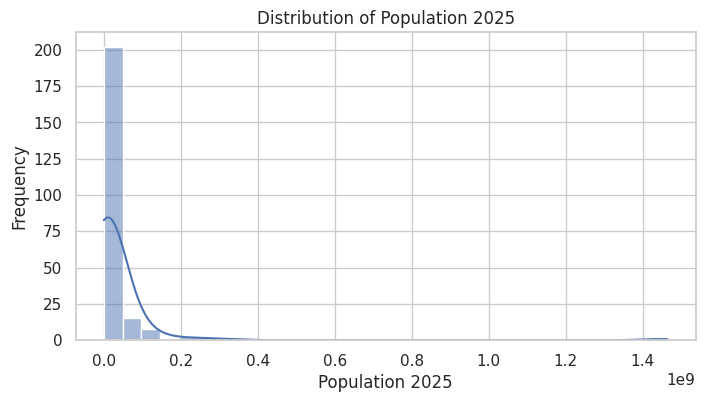

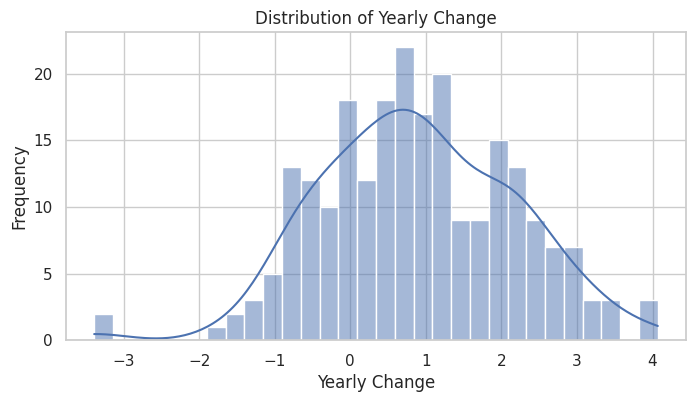

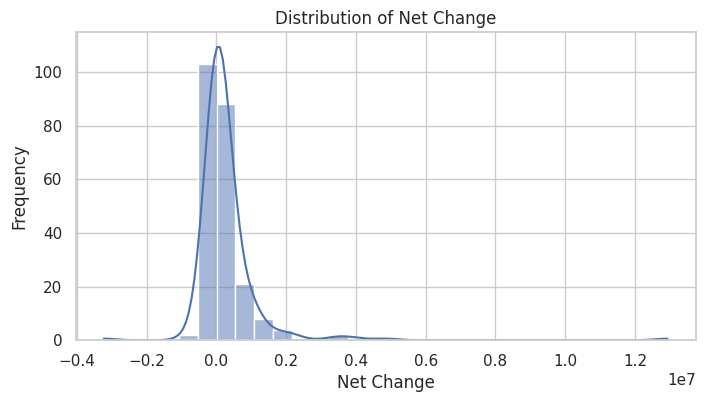

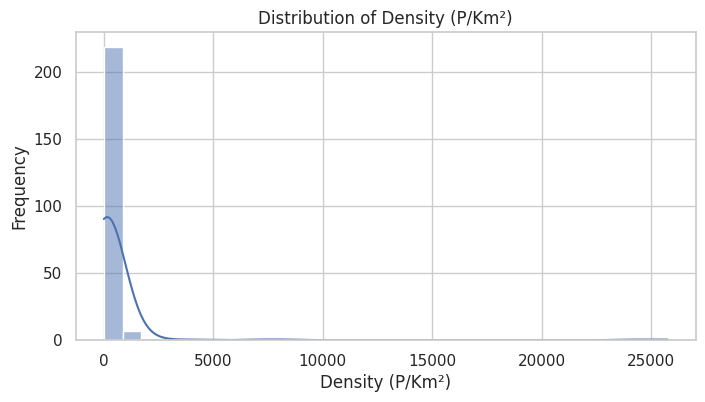

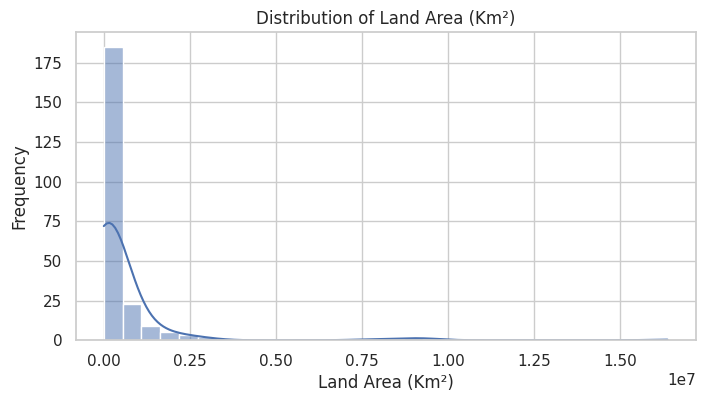

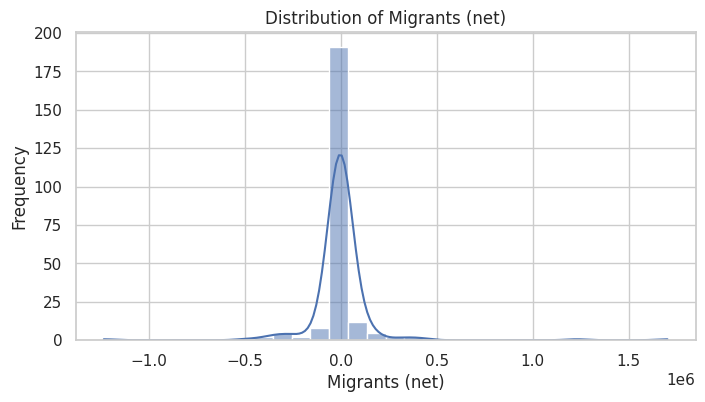

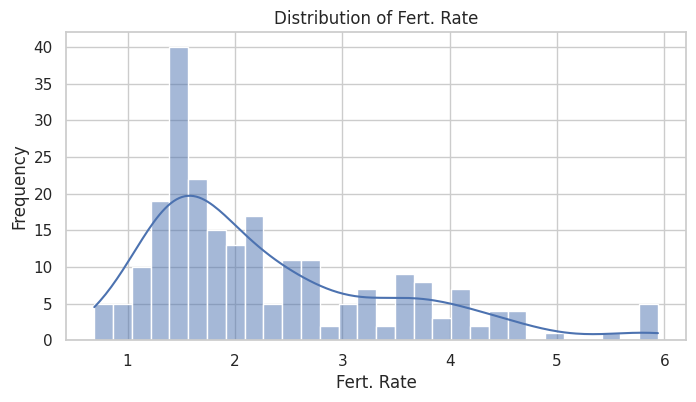

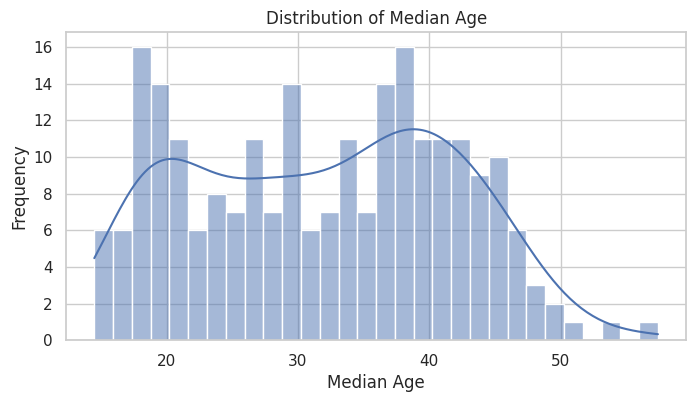

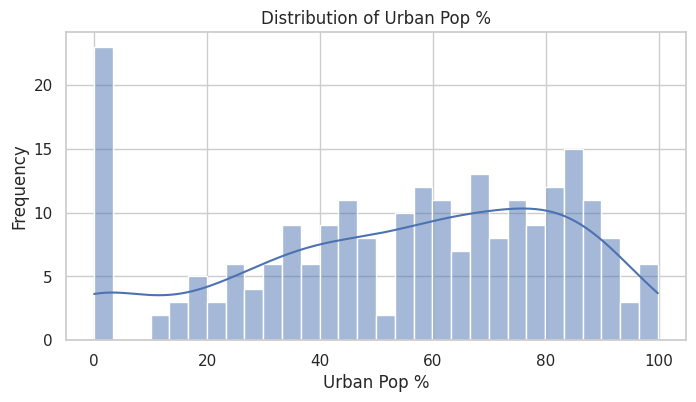

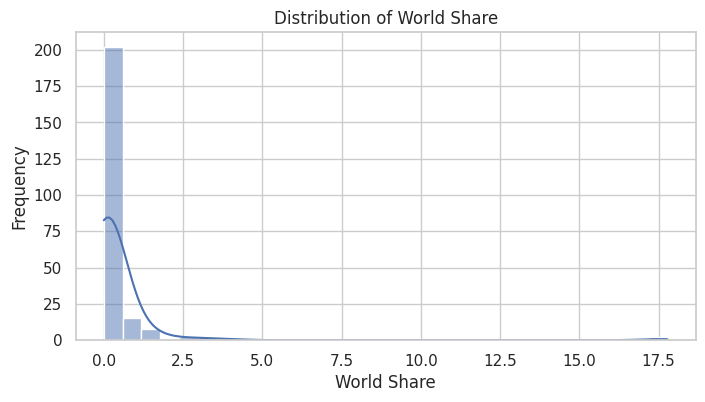

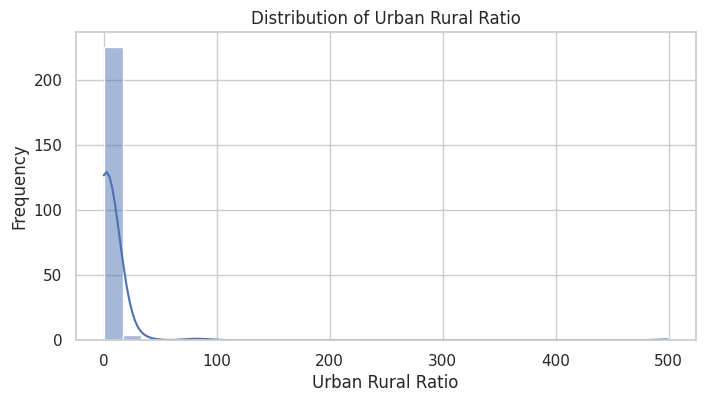

In [ ]:
# numeric columns only
numeric_cols = df_analysis.select_dtypes(include=['number']).columns

# removing # which numbers the rows
numeric_cols = [col for col in numeric_cols if col != "#"]

#style
sns.set(style="whitegrid")

# histograms + KDE curves
for col in numeric_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df_analysis[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


*Distribution of Population*

This histogram shows that most countries have small populations, which is why the bars are clustered on the left. The long tail on the right means only a few countries, like India and China, have extremely large populations. This creates a strong right-skewed distribution.


*Distribution of Yearly Change*

This chart shows how countries differ in their yearly population change. Most countries fall around 0–1%, meaning their populations are growing slowly. Some countries have higher growth rates around 2–3%.
There are also a few countries with negative growth on the left side, but they are much fewer.
Overall, the distribution is moderately spread out, showing that yearly change varies, but most countries cluster near the middle.

*Distribution of Net Change*

This plot shows that most countries have very small net population changes, which is why the bars are crowded around zero. Only a few countries have very large increases or decreases, creating long tails on both sides. This means net change is mostly stable for most countries, with only a few extreme outliers

*Distribution of Density*

This plot shows that most countries have low population density, which is why the tallest bars are packed on the left side. Only a few countries have extremely high density, creating a long tail stretching to the right. This means the distribution is very right-skewed.


*Distribution of Land Area*

Shows that most countries have very small land areas, which is why the bars appear tightly grouped on the left side.
Only a few countries—such as Russia, Canada, China, and the United States—have extremely large land areas. This makes the distribution strongly right-skewed.

*Distribution of Migrants*

 Most countries have values very close to zero, meaning they have only small positive or negative migration changes. The curve is tall and narrow in the center, showing that migration numbers are heavily concentrated around zero. Overall, the distribution is strongly peaked and centered near zero.

*Distribution of Fertility Rate*

 The fertility rate distribution is right-skewed, meaning most countries have lower fertility rates between 1.3 and 2.5, while only a few countries have very high rates above 4 or 5.


*Distribution of Median Age*

Young populations (median age in the low 20s, common in Africa and parts of Asia)
Older populations (median age 40-50, common in Europe and East Asia). It shows a wide range, revealing global demographic differences.


*Distribution of Urban Population*

Most countries have moderate to high urbanization (40-80%). A few are highly urbanized with 90%+ of people living in cities, while some remain largely rural. The distribution leans right, showing urbanization is common globally.


*Distribution of World Share*

Most countries contribute very small percentages to the global population. Only a few countries - primarily India, China, and the United States - hold a significant share of the world’s population.

## **5.2 Scatter Plots**

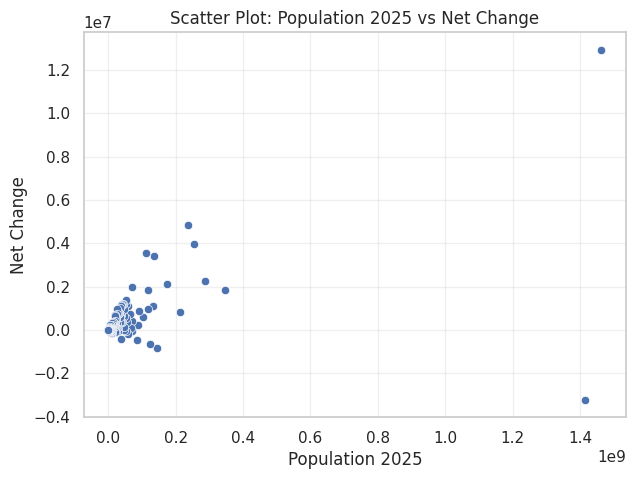

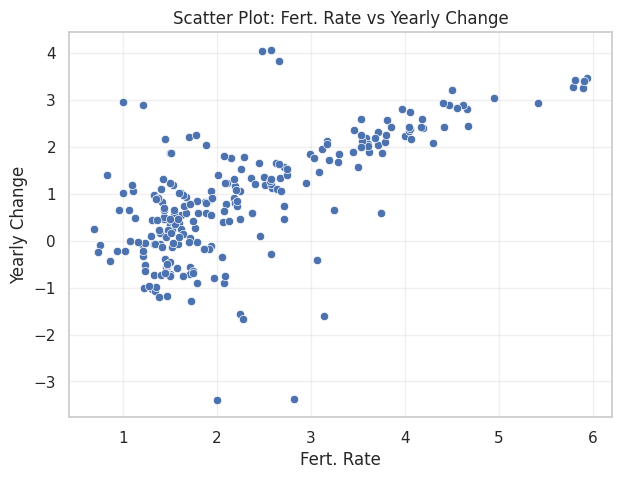

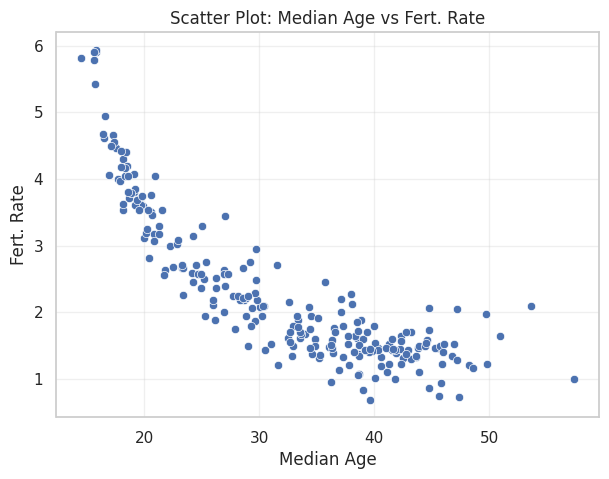

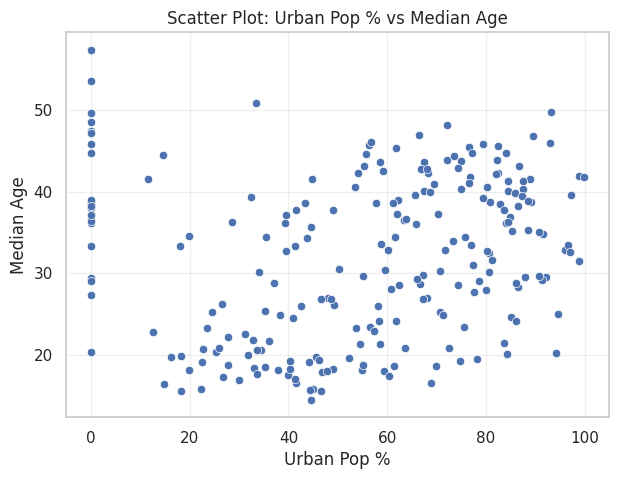

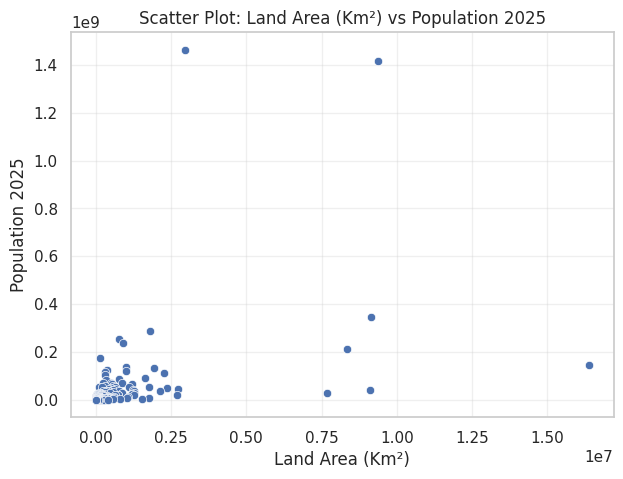

In [ ]:
# numeric columns only
df_num = df_analysis.select_dtypes(include='number')

# choosing pairs to visualize
pairs = [
    ("Population 2025", "Net Change"),
    ("Fert. Rate", "Yearly Change"),
    ("Median Age", "Fert. Rate"),
    ("Urban Pop %", "Median Age"),
    ("Land Area (Km²)", "Population 2025")
]

# creating scatter plots
for x, y in pairs:
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=df_analysis, x=x, y=y)
    plt.title(f"Scatter Plot: {x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(True, alpha=0.3)
    plt.show()

## **5.3 Heat Maps**

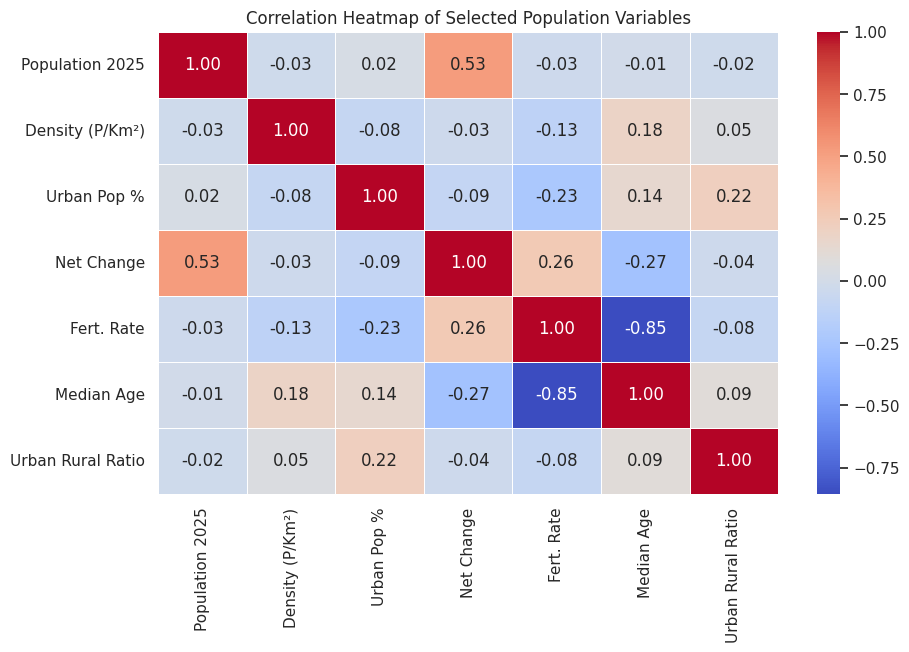

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Selected Population Variables")
plt.show()


The heatmap visualizes the relationships between key population variables for different countries. Each cell shows a correlation value between −1 and +1:

**Red** = strong positive correlation (variables increase together)

**Blue** = strong negative correlation (one increases while the other decreases)

**White/light colors** = weak or no relationship




Fertility Rate & Median Age (r = −0.85)

This is the strongest relationship in the entire heatmap.

High fertility rates are found in countries with low median ages, and vice versa.

This makes demographic sense: younger populations tend to have higher birth rates.



Population 2025 & Net Change (r = 0.53)

Countries with larger populations tend to show higher net population growth.

Urban Pop % with others (weak correlations)

Urbanization shows very small correlations with most variables (close to 0).

This suggests urbanization varies independently from population size, density, or fertility.

## **5.4 Bar Plots**

/tmp/ipython-input-3233180085.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-3233180085.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


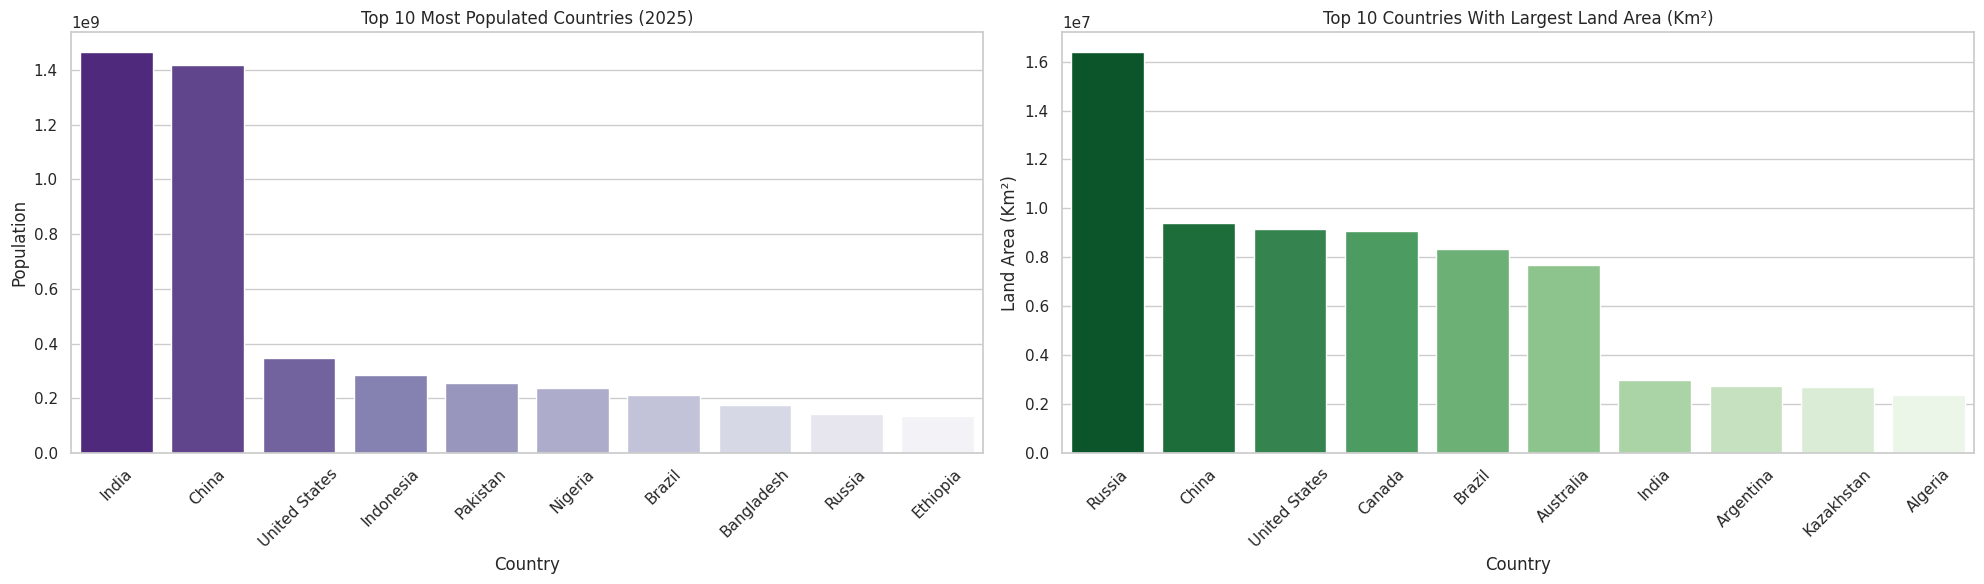

<Figure size 640x480 with 0 Axes>

In [ ]:
# reading the cleaned dataset
df = pd.read_csv("world_pop_cleaned.csv")

# Top 10 counries (largest population)
top_population = df.nlargest(10, "Population 2025")

# Top 10 counries (largest area)
top_area = df.nlargest(10, "Land Area (Km²)")

# for good appeareance we chise side by side (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# First plot (Population( ---)
sns.barplot(
    ax=axes[0],  # plot on the first axes (left)
    x=top_population["Country (or dependency)"],  # x-axis - country names
    y=top_population["Population 2025"],         # y-axis - population
    palette="Purples_r"                           # color palette
)
axes[0].set_title("Top 10 Most Populated Countries (2025)")  # Plot title
axes[0].set_xlabel("Country")                                 # x-axis label
axes[0].set_ylabel("Population")                              # y-axis label
axes[0].tick_params(axis='x', rotation=45)                    # rotation of x-axis labels

# Second plot: (Area)
sns.barplot(
    ax=axes[1],
    x=top_area["Country (or dependency)"],
    y=top_area["Land Area (Km²)"],
    palette="Greens_r"
)
axes[1].set_title("Top 10 Countries With Largest Land Area (Km²)")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Land Area (Km²)")
axes[1].tick_params(axis='x', rotation=45)

# layout setting that plots don't overlap
plt.tight_layout()

# display
plt.show()

# saving
plt.savefig('analysis1.png')


/tmp/ipython-input-983609573.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=density_counts.index, y=density_counts.values, ax=axes[0, 1], palette="rocket")
/tmp/ipython-input-983609573.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fertility_counts.index, y=fertility_counts.values, ax=axes[1, 0], palette="viridis")
/tmp/ipython-input-983609573.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=urban_counts.index, y=urban_counts.values, ax=axes[1, 1], palette="cividis")


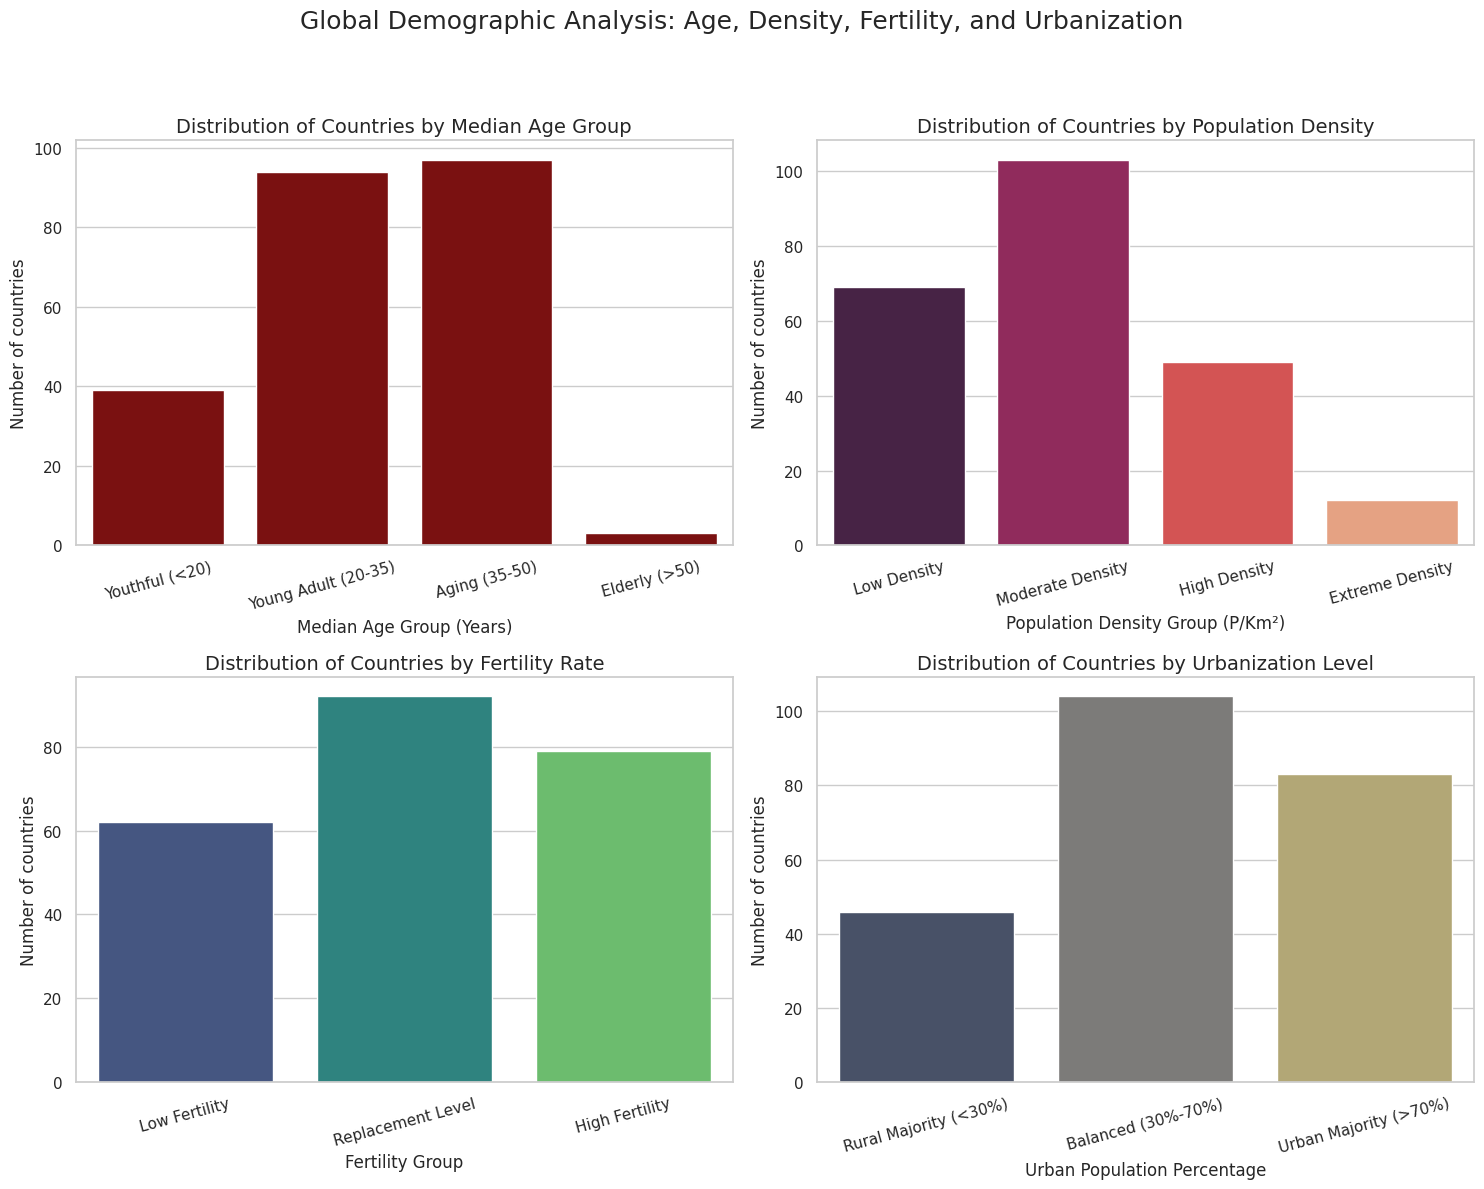

In [ ]:
# dataset
file_name = "world_pop_cleaned.csv"
try:
    df = pd.read_csv(file_name)
except FileNotFoundError:
    # creating a comprehensive dummy DataFrame if file is not found
    np.random.seed(42)
    n_countries = 200
    df = pd.DataFrame({
        'Country (or dependency)': [f'Country {i}' for i in range(n_countries)],
        'Population 2025': np.concatenate([np.random.lognormal(mean=14, sigma=2, size=180), np.random.lognormal(mean=20, sigma=1, size=20)]),
        'Density (P/Km²)': np.concatenate([np.random.lognormal(mean=2, sigma=1.5, size=180), np.random.lognormal(mean=6, sigma=1.5, size=20)]),
        'Fert. Rate': np.concatenate([np.random.uniform(0.8, 1.4, 60), np.random.uniform(1.8, 2.4, 100), np.random.uniform(3.0, 6.0, 40)]),
        'Urban Pop %': np.clip(np.random.normal(55, 20, n_countries), 5, 100),
        'Median Age': np.clip(np.random.normal(30, 10, n_countries), 15, 50)
    })
    df = df.sample(frac=1).reset_index(drop=True)

# Feauter engineering for categorical plots

# median age group (new)
bins_age = [0, 20, 35, 50, np.inf]
labels_age = ['Youthful (<20)', 'Young Adult (20-35)', 'Aging (35-50)', 'Elderly (>50)']
df['Age_Group'] = pd.cut(df['Median Age'], bins=bins_age, labels=labels_age, right=False)

# density group (keep)
bins_dens = [0, 50, 250, 1000, np.inf]
labels_dens = ['Low Density', 'Moderate Density', 'High Density', 'Extreme Density']
df['Density_Group'] = pd.cut(df['Density (P/Km²)'], bins=bins_dens, labels=labels_dens, right=False)

# fertility Group (keep)
bins_fert = [0, 1.5, 2.5, np.inf]
labels_fert = ['Low Fertility', 'Replacement Level', 'High Fertility']
df['Fertility_Group'] = pd.cut(df['Fert. Rate'], bins=bins_fert, labels=labels_fert, right=False)

# urbanization Group (keep)
bins_urban = [0, 30, 70, 101]
labels_urban = ['Rural Majority (<30%)', 'Balanced (30%-70%)', 'Urban Majority (>70%)']
df['Urban_Group'] = pd.cut(df['Urban Pop %'], bins=bins_urban, labels=labels_urban, right=False)


# 2x2 subplots

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
plt.suptitle('Global Demographic Analysis: Age, Density, Fertility, and Urbanization', fontsize=18, y=1.02)

# first plot (Top-Left) - Distribution by Median Age Group
age_counts = df['Age_Group'].value_counts().sort_index()
sns.barplot(x=age_counts.index, y=age_counts.values, ax=axes[0, 0], color="darkred")
axes[0, 0].set_title("Distribution of Countries by Median Age Group", fontsize=14)
axes[0, 0].set_xlabel("Median Age Group (Years)")
axes[0, 0].set_ylabel("Number of countries")
axes[0, 0].tick_params(axis='x', rotation=15)

# second plot (Top-Right) - Distribution by Density Group
density_counts = df['Density_Group'].value_counts().sort_index()
sns.barplot(x=density_counts.index, y=density_counts.values, ax=axes[0, 1], palette="rocket")
axes[0, 1].set_title('Distribution of Countries by Population Density', fontsize=14)
axes[0, 1].set_xlabel('Population Density Group (P/Km²)')
axes[0, 1].set_ylabel('Number of countries')
axes[0, 1].tick_params(axis='x', rotation=15)

# third plot (Bottom-Left) - Distribution by Fertility Group
fertility_counts = df['Fertility_Group'].value_counts().sort_index()
sns.barplot(x=fertility_counts.index, y=fertility_counts.values, ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title('Distribution of Countries by Fertility Rate', fontsize=14)
axes[1, 0].set_xlabel('Fertility Group')
axes[1, 0].set_ylabel('Number of countries')
axes[1, 0].tick_params(axis='x', rotation=15)

# forth plot (Bottom-Right) - Distribution by Urbanization Group
urban_counts = df['Urban_Group'].value_counts().sort_index()
sns.barplot(x=urban_counts.index, y=urban_counts.values, ax=axes[1, 1], palette="cividis")
axes[1, 1].set_title('Distribution of Countries by Urbanization Level', fontsize=14)
axes[1, 1].set_xlabel('Urban Population Percentage')
axes[1, 1].set_ylabel('Number of countries')
axes[1, 1].tick_params(axis='x', rotation=15)


# adjusting spacing between subplots
fig.tight_layout(rect=[0, 0.03, 1, 0.98])

#saving
plt.savefig('analysis2.png')

## **5.5 Box Plots**

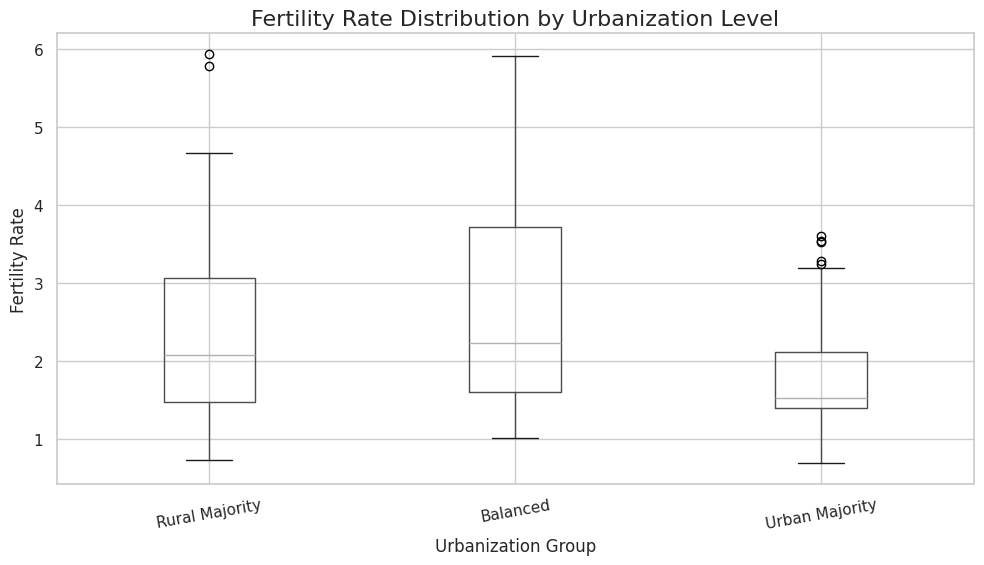

In [ ]:
df = pd.read_csv("world_pop_cleaned.csv")

# Feautre Engineering (Creating categorical group)

# Define bins and labels for Urban Population Percentage
bins_urban = [0, 30, 70, 101]
labels_urban = ['Rural Majority', 'Balanced', 'Urban Majority']
df['Urban_Group'] = pd.cut(df['Urban Pop %'], bins=bins_urban, labels=labels_urban, right=False)


# generating single box plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# (using pandas.boxplot style)
df.boxplot(column='Fert. Rate', by='Urban_Group', ax=ax)

ax.set_title('Fertility Rate Distribution by Urbanization Level', fontsize=16)
ax.set_xlabel('Urbanization Group')
ax.set_ylabel('Fertility Rate')
ax.tick_params(axis='x', rotation=10)

# removinmg the default title created by df.boxplot
plt.suptitle('')

plt.tight_layout()
plt.savefig('analysis3.png', dpi=300)
plt.show()
plt.close()


# ***6. Results Explanation***

## **6.1 Interpretation the results of the analysis.**

After cleaning and analyzing the population dataset, we were able to clearly see several important patterns.

First, the results showed that a few countries have extremely large populations, while most countries fall into much smaller ranges.

The graphs also helped us see that land size doesn't always match population size. Big countries like Canada and Russia have large land areas but low population density, while some smaller countries are very densely populated.


We also found strong relationships between demographic factors. For example, countries with high fertility rates usually had much younger populations, and countries with low fertility had older populations.

This was confirmed both in the correlation heatmap and in the visualizations.

Another clear finding was that urbanization affects fertility: countries with higher urban populations generally had lower fertility rates.

## **6.2 The implications and potential applications of the findings.**

These results are useful because they help explain how different countries are developing and what challenges they might face.

Countries with aging populations may need more healthcare and support for older citizens, while younger countries may need more schools and jobs.

Understanding population density can help with housing, city planning, and resource management.


Our findings about urbanization and fertility can be used by governments when making decisions about family policies, rural development, and city planning.

Migration trends can help countries prepare for increases or decreases in population. Overall, this analysis can support better decisions in areas like education, healthcare, economy, and long-term population planning.